In [1]:
# Put the project directory on the path to make sure we can import PyNitride
import sys, os
sys.path.append(os.path.abspath("../"))

In [2]:
%matplotlib notebook
import numpy as np
from scipy.linalg import norm
from pynitride import ParamDB, Material
from pynitride.bandstruct.kp import kp_6x6
from pynitride.bandstruct.reciprocal import generate_path
import matplotlib.pyplot as plt
pmdb=ParamDB(units='neu')
to_units=pmdb.to_units
q,hbar,m_e,nm=pmdb.get_constants("e,hbar,m_e,nm")
GaN=Material("GaN",pmdb=pmdb)
pa=np.pi/GaN['lattice.a']

In [3]:
GaN=Material("GaN")
AlN=Material("AlN")
a0=GaN['lattice.a']
c0=GaN['lattice.c']
a=AlN['lattice.a']
C13oC33=GaN['stiffness.C13']/GaN['stiffness.C33']
st=(a-a0)/a0
sz=-2*C13oC33*st

In [12]:
kmax=1.5/nm
kvecsx=generate_path(points=[[0,0,0],[kmax,0,0]],n=500)
kx=norm(kvecsx,axis=1)
bs_kx=kp_6x6(GaN,kvecsx,[st,st,sz],spin_orbit=True)
kvecsz=generate_path(points=[[0,0,0],[0,0,kmax]],n=500)
kz=norm(kvecsz,axis=1)
bs_kz=kp_6x6(GaN,kvecsz,[st,st,sz],spin_orbit=True)

<IPython.core.display.Javascript object>


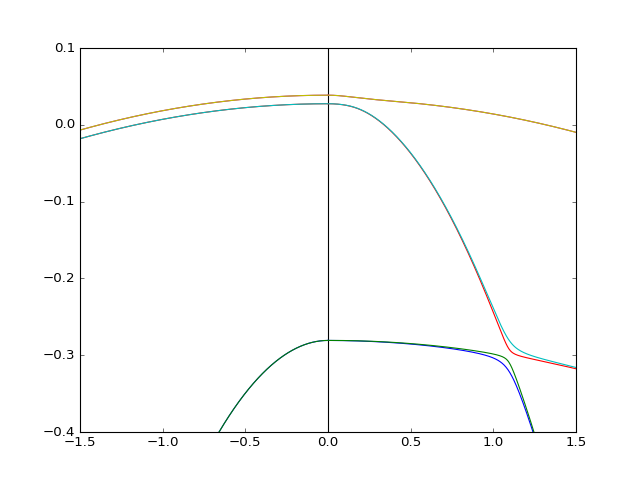

In [17]:
plt.figure()
plt.plot(kx,bs_kx)
plt.plot(-kz,bs_kz)
plt.ylim(-.4,.1)
plt.vlines(0,-.4,.1)

In [34]:
bs_kz[499,:]

array([-0.8987107 , -0.8987107 , -0.01813443, -0.01813443, -0.00687404,
       -0.00687404,  4.08399532])

In [18]:
from scipy import gradient

In [37]:
def print_eff_mass(bs,k,p):
    n=len(k)
    for i in reversed(2*np.arange(3)):
        x=("E0={:7.3f}".format(bs[0,i]))
        x+=("     m={:7.3f}".format(-1/(2*m_e/hbar**2*(bs[p,i]-bs[0,i])/norm(k[p])**2)))
        x+=("     m'={:7.3f}".format(-hbar**2/(m_e*gradient(gradient(bs[:,i]))[p]/(norm(k[1,:])-norm(k[0]))**2)))
        print(x)
def plot_eff_mass(bs,k,i=4):
    #print(bs[:,i])
    m=-1/(2*m_e/hbar**2*(bs[:,i]-bs[0,i])/k**2)
    mp=-hbar**2/(m_e*gradient(gradient(bs[:,i]))/(k[1]-k[0])**2)
    #print(m)
    #print(mp)
    plt.plot(k,m)
    plt.plot(k,mp,'--')
    plt.ylim(0,2.5)

<IPython.core.display.Javascript object>


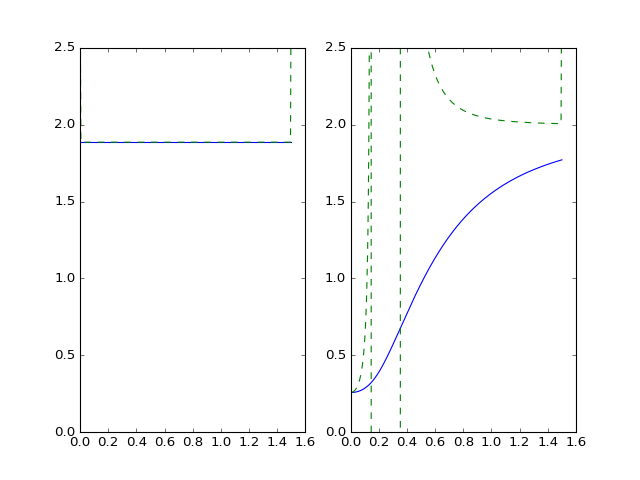

In [38]:
#HH
plt.figure()
plt.subplot(121)
plot_eff_mass(bs_kz,kz)
plt.subplot(122)
plot_eff_mass(bs_kx,kx)

<IPython.core.display.Javascript object>


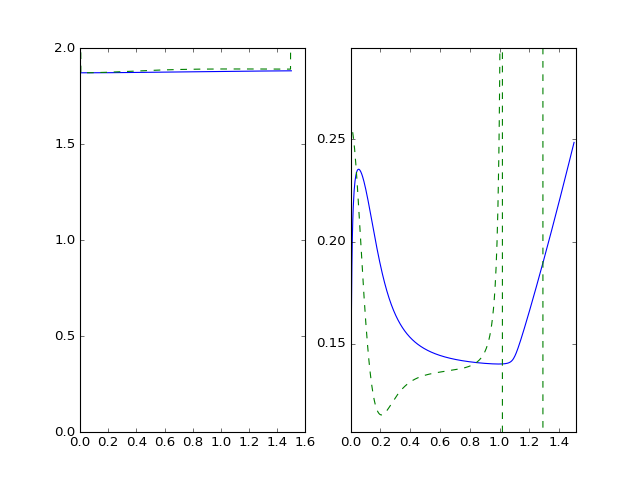

In [35]:
#LH
plt.figure()
plt.subplot(121)
plot_eff_mass(bs_kz,kz,i=2)
plt.subplot(122)
plot_eff_mass(bs_kx,kx,i=2)

<IPython.core.display.Javascript object>


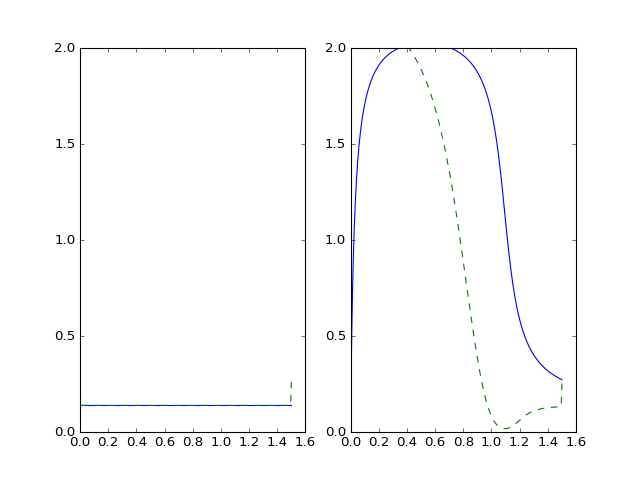

In [36]:
#CH
plt.figure()
plt.subplot(121)
plot_eff_mass(bs_kz,kz,i=0)
plt.subplot(122)
plot_eff_mass(bs_kx,kx,i=0)

In [40]:
print("no SO")
print("x")
print_eff_mass(np.flipud(bs_r_n[:500]),np.flipud(kvecs[:500]),5)
print("y")
print_eff_mass((bs_r_n[499:]),(kvecs[499:]),5)
print("\n")
print("SO")
print("x")
print_eff_mass(np.flipud(bs_r_so[:500]),np.flipud(kvecs[:500]),5)
print("y")
print_eff_mass((bs_r_so[499:]),(kvecs[499:]),5)

no SO
x
E0=  0.000     m=  1.887     m'=  1.887
E0=  0.000     m=  1.887     m'=  1.887
E0= -0.010     m=  0.139     m'=  0.139
y
E0=  0.000     m=  2.000     m'=  2.000
E0=  0.000     m=  0.146     m'=  0.147
E0= -0.010     m=  1.107     m'=  1.091


SO
x
E0=  0.000     m=  1.887     m'=  1.887
E0= -0.005     m=  0.334     m'=  0.337
E0= -0.022     m=  0.211     m'=  0.209
y
E0=  0.000     m=  0.269     m'=  0.264
E0= -0.005     m=  0.054     m'=  0.322
E0= -0.022     m=  0.057     m'=  0.527


strained
---

In [41]:
print("no SO")
print("x")
print_eff_mass(np.flipud(bs_s_n[:500]),np.flipud(kvecs[:500]),5)
print("y")
print_eff_mass((bs_s_n[499:]),(kvecs[499:]),5)
print("\n")
print("SO")
print("x")
print_eff_mass(np.flipud(bs_s_so[:500]),np.flipud(kvecs[:500]),5)
print("y")
print_eff_mass((bs_s_so[499:]),(kvecs[499:]),5)

no SO
x
E0=  0.039     m=  1.887     m'=  1.887
E0=  0.039     m=  1.887     m'=  1.887
E0= -0.275     m=  0.139     m'=  0.139
y
E0=  0.039     m=  2.000     m'=  2.000
E0=  0.039     m=  0.137     m'=  0.137
E0= -0.275     m=  2.199     m'=  2.199


SO
x
E0=  0.039     m=  1.887     m'=  1.887
E0=  0.027     m=  1.871     m'=  1.871
E0= -0.281     m=  0.139     m'=  0.139
y
E0=  0.039     m=  0.257     m'=  0.260
E0=  0.027     m=  0.210     m'=  0.253
E0= -0.281     m=  0.764     m'=  2.186


strained at 100
---

In [43]:
print("SO")
print("x")
print_eff_mass(np.flipud(bs_s_so[:500]),np.flipud(kvecs[:500]),100)
print("y")
print_eff_mass((bs_s_so[499:]),(kvecs[499:]),100)

SO
x
E0=  0.039     m=  1.887     m'=  1.887
E0=  0.027     m=  1.872     m'=  1.877
E0= -0.281     m=  0.139     m'=  0.139
y
E0=  0.039     m=  0.569     m'= -3.216
E0=  0.027     m=  0.164     m'=  0.124
E0= -0.281     m=  1.983     m'=  2.089


In [23]:
bs_s_so[499][6]-bs_s_so[499][5]

3.6168123414269675

In [24]:
bs_r_so[499][6]-bs_r_so[499][5]

3.4376017699115038

In [25]:
bs_s_so[499][6]-bs_r_so[499][6]

0.21777057126334043

In [26]:
Material("AlN")["Eg"]

6.139999999999999

In [27]:
Material("AlN")["electron.DEc"]-(bs_s_so[499][6]-bs_r_so[499][6])

1.6172294287366593

AlN
===

In [28]:
aln_bs_r_so=kp_6x6(AlN,kvecs,[0,0,0],spin_orbit=True)

In [29]:
plot_bs(pseudo_k,aln_bs_r_so,color='r')
#plot_bs(pseudo_k,bs_r_so,color='r',new_fig=False)
plt.title("Relaxed: SO")# versus no SO")

<IPython.core.display.Javascript object>

In [30]:
print("SO")
print("x")
print_eff_mass(np.flipud(aln_bs_r_so[:500]),np.flipud(kvecs[:500]),100)
print("z")
print_eff_mass((aln_bs_r_so[499:]),(kvecs[499:]),100)

SO
x


NameError: name 'print_eff_mass' is not defined